Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>


Fri, 15 May 2026 14:07 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
Fri, 15 May 2026 14:07 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
100%|██████████| 101/101 [00:00<00:00, 106.79it/s]


[0.69268965 0.86401523 1.07739933 1.28809657 1.47381646 1.61421343
 1.68769765 1.6914082  1.69264176 1.6937568  1.69527924 1.69665766
 1.69808808 1.69944517 1.70089109 1.70253864 1.70389017 1.70526037
 1.70640521 1.7077175  1.70856721 1.70963011 1.71037871 1.71089679
 1.71123172 1.71132122 1.71158    1.71147203 1.71119449 1.71072698
 1.71001395 1.70936003 1.70849784 1.70740226 1.7063823  1.70528646
 1.70406105 1.70290523 1.70186069 1.70033616 1.69927382 1.6983345
 1.69733079 1.69621074 1.69375078 1.64169537 1.54082227 1.40712795
 1.25549618 1.10337964 0.98337901 1.10326438 1.25555008 1.40710075
 1.54090659 1.64155301 1.6935519  1.69624909 1.69725707 1.69813536
 1.69940108 1.70052912 1.70165314 1.70273542 1.70389823 1.70525243
 1.70632387 1.70739889 1.70826466 1.70927328 1.70983149 1.71063549
 1.71111755 1.71137567 1.71145053 1.71128339 1.71128305 1.71091192
 1.71037273 1.70963894 1.70864178 1.7077189  1.70657623 1.70517818
 1.70390182 1.70250748 1.70097987 1.69953746 1.69823242 1.69644

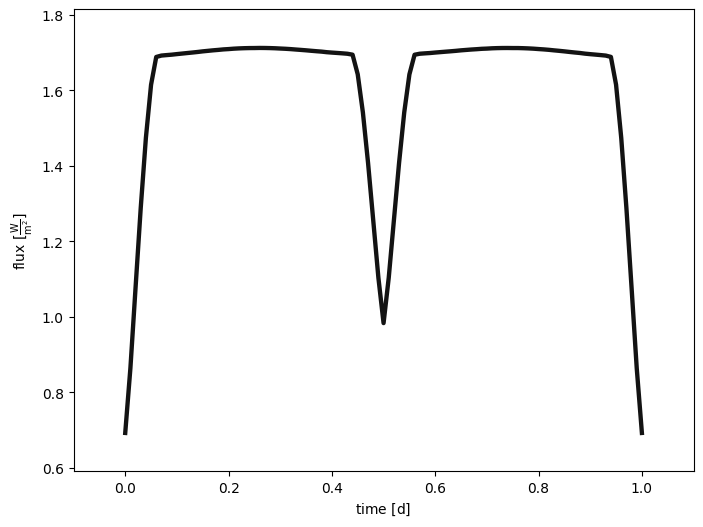

In [1]:
import matplotlib.pyplot as plt
import phoebe
from phoebe import u #units

%matplotlib inline

logger = phoebe.logger(clevel='WARNING')

b = phoebe.default_binary()
b.set_value(qualifier='teff', component='primary', value=6500)
b.add_dataset('lc',compute_times=phoebe.linspace(0,1,101))
b.run_compute()

print(b.get_value(qualifier='fluxes', context='model'))

afig, mplfig = b.plot(show=True)

In [2]:
b.filter(
    context='compute',
    component='primary',
    qualifier='ntriangles'
).get_parameter()

print(
    b.filter(
        context='compute',
    ).info
)

b.get_parameter(component='primary', qualifier='ntriangles').set_value(2000)

b.get_parameter(
    component='secondary',
    qualifier='distortion_method',
).get_choices()
b.get_parameter(
    component='secondary',
    qualifier='distortion_method'
).set_value('rotstar')
b.get_parameter(
    component='secondary',
    qualifier='distortion_method'
).get_value()

b['distortion_method@primary@compute'] = 'roche'

print(b['value@distortion_method@primary'])

ParameterSetInfo: (qualfier/twig: description)
                             atm: Atmosphere table
                 boosting_method: Type of boosting method
                        comments: User-provided comments for these compute-options.  Feel free to place any notes here - if not overridden, they will be copied to any resulting models.
               distortion_method: Method to use for distorting stars
                 dynamics_method: Which method to use to determine the dynamics of components
                  eclipse_method: Type of eclipse algorithm
                         enabled: Whether to create synthetics in compute/solver run
                      fti_method: How to handle finite-time integration (when non-zero exptime)
                  horizon_method: Type of horizon method
                    irrad_method: Which method to use to handle all irradiation effects (reflection)
                            ltte: Correct for light travel time effects
                     mesh

In [3]:
phoebe.list_available_datasets()

b.add_dataset(phoebe.dataset.orb,
              compute_times=phoebe.linspace(0,10,20),
              dataset='orb01',
              component=['primary', 'secondary'],
              overwrite=True
)



<ParameterSet: 50 parameters | contexts: compute, dataset, constraint, figure>

Fri, 15 May 2026 14:34 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
100%|██████████| 101/101 [00:00<00:00, 111.59it/s]
Fri, 15 May 2026 14:34 BUNDLE       WARNING overwriting model: latest
Fri, 15 May 2026 14:34 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
100%|██████████| 1100/1100 [00:02<00:00, 543.05it/s]


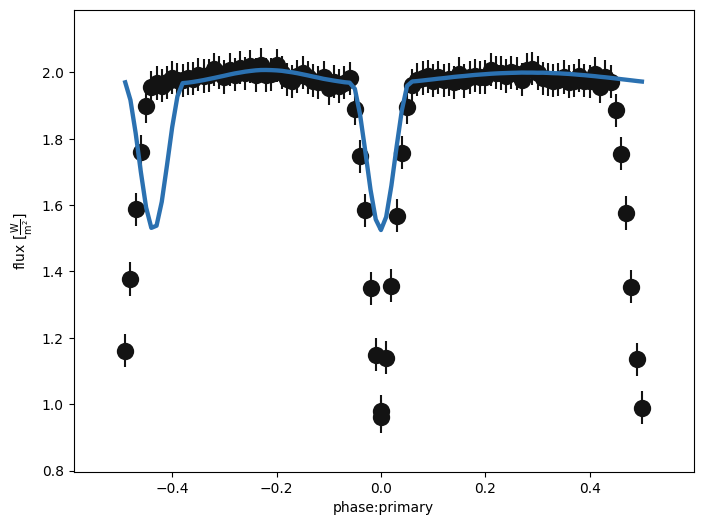

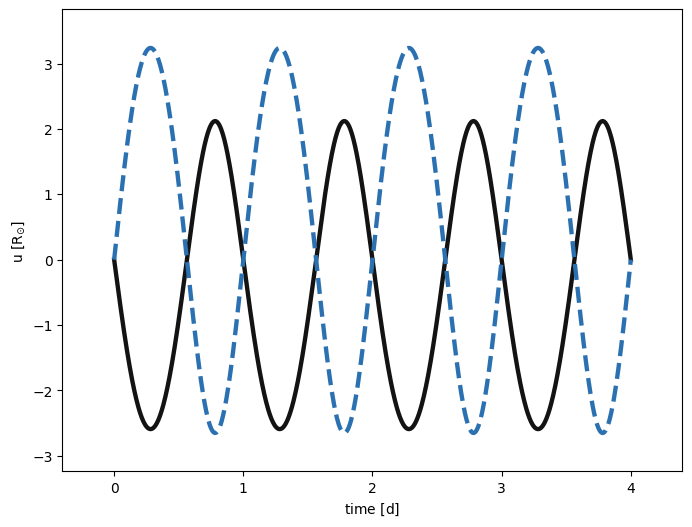

In [19]:
import numpy as np

b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0,1,101))
b.run_compute(irrad_method='none')

times = b.get_value('times', context='model')
fluxes = b.get_value('fluxes', context='model') + np.random.normal(size=times.shape) * 0.01
sigmas = np.ones_like(times) * 0.05

b.set_value('q', 0.8)
b.set_value('ecc', 0.1)
b.set_value('incl@orbit', 80)
b.set_value('irrad_method', 'none')

b.add_dataset('orb',
              compute_times=np.linspace(0,4,1000),
              dataset='orb01',
              component=['primary', 'secondary'],
              overwrite=True
)
b.add_dataset('lc', times=times, fluxes=fluxes, sigmas=sigmas, dataset='lc01', overwrite=True)

b.run_compute(irrad_method='none')

afig, mplfig = b.plot(dataset='lc01', x='phases:primary', show=True)

b.filter(context='model', dataset='orb01').qualifiers
afig, mplfig = b.plot(dataset='orb01', x='times', y='us', show=True)

3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
2.4.22
